In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "50"
os.environ["MKL_NUM_THREADS"] = "50"
os.environ["OPENBLAS_NUM_THREADS"] = "50"
os.environ["NUMEXPR_NUM_THREADS"] = "50"

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import classA_U1FGTN
importlib.reload(classA_U1FGTN)
from classA_U1FGTN import classA_U1FGTN


In [79]:

# Lattice + DW parameters and circuit depth
Nx, Ny   = 12, 100
alpha_1, alpha_2 = 30, 1

# Build model and run adaptive circuit; keep history in memory, avoid cache saves
model = classA_U1FGTN(Nx, Ny, nshell=None, DW=True, alpha_1=alpha_1, alpha_2=alpha_2)
G_gs = model.G_CI_domain_wall()

DWs at x=(4, 8)
------------------------- classA_U1FGTN Initialized -------------------------


{'shape_ok': True, 'Ny': 100, 'shift_max_abs_diff': 9.147404559092391e-15, 'shift_pass': True, 'offdiag_ratio': 2.6670954322983888e-28, 'offdiag_pass': True}


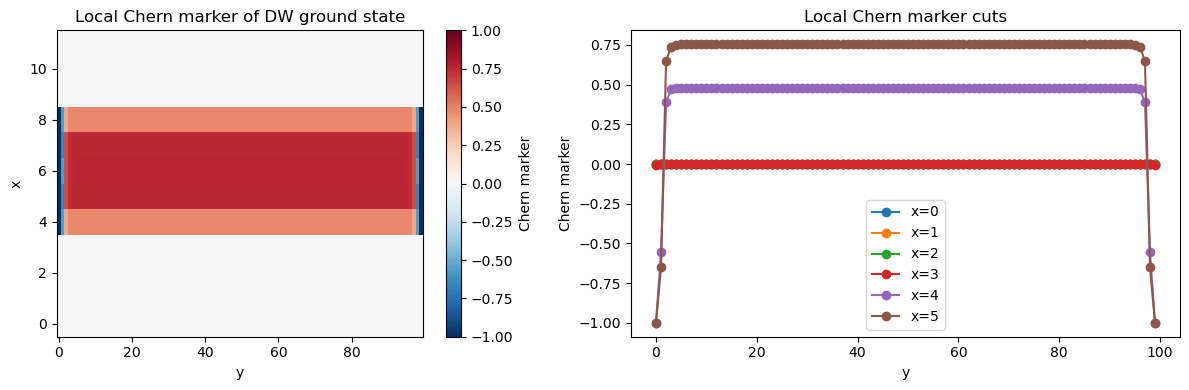

In [80]:

# Local Chern marker to verify DW composition
chern_map = model.local_chern_marker_flat(G_gs)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [1, 1.2]})

im = axes[0].imshow(chern_map, origin="lower", cmap="RdBu_r", aspect="auto", vmin=-1, vmax=1)
fig.colorbar(im, ax=axes[0], label="Chern marker")
axes[0].set_title("Local Chern marker of DW ground state")
axes[0].set_xlabel("y")
axes[0].set_ylabel("x")

res = model.check_y_translation_invariance(G_gs)
print(res)

for x in range(6):
    axes[1].plot(chern_map[x, :], marker='o', label=f"x={x}")
axes[1].legend()
axes[1].set_title('Local Chern marker cuts')
axes[1].set_xlabel("y")
axes[1].set_ylabel("Chern marker")

plt.tight_layout()
plt.show()


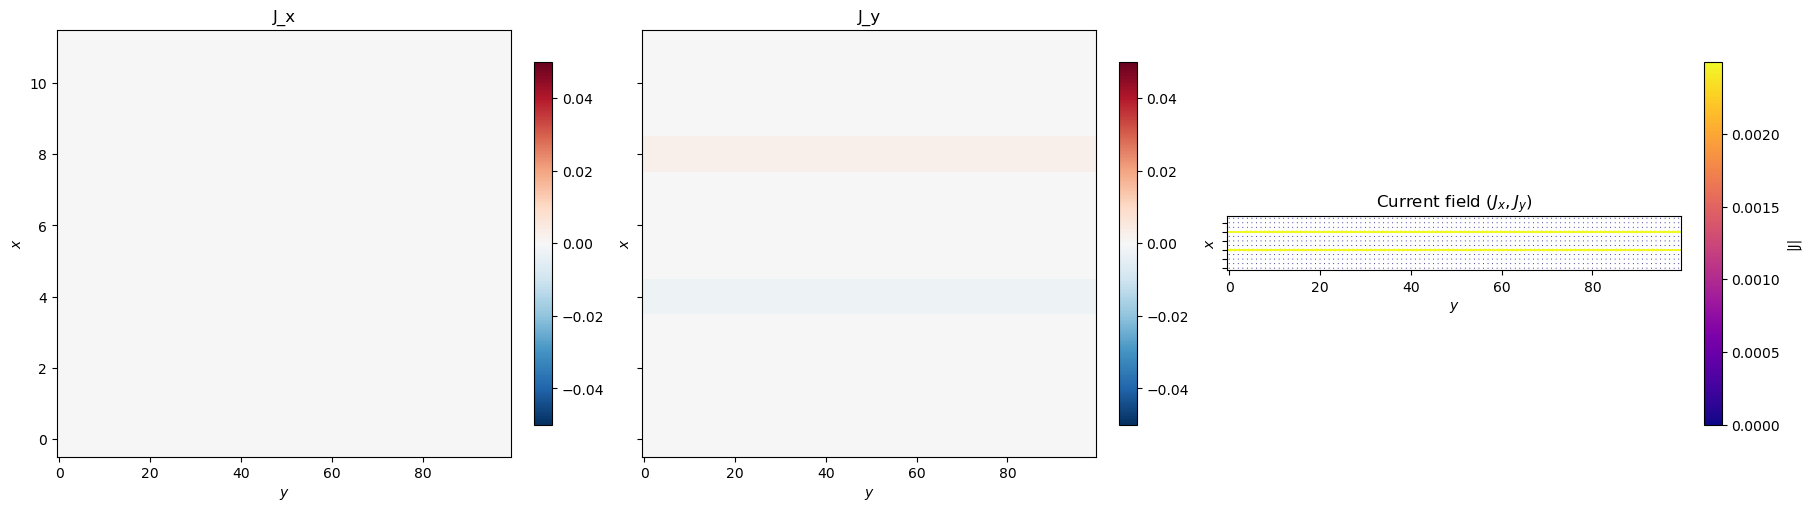

In [83]:

J_x, J_y = model.current_maps_gauge_invariant(G_gs)
fig, axes = model.plot_current_maps(J_x, J_y, figsize=(18, 5), sharey=True, vmin=-0.05, vmax=+0.05)
plt.show()

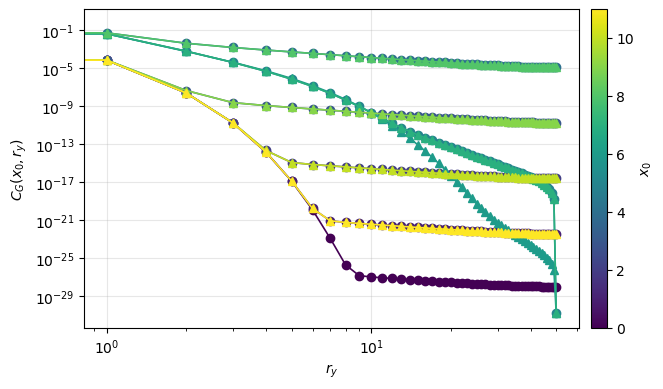

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from classA_U1FGTN import classA_U1FGTN

# Top-layer covariance
Nlayer = model.Ntot // 2
if G_gs.shape[0] == model.Ntot:
    G_top = G_gs[:Nlayer, :Nlayer]
elif G_gs.shape[0] == Nlayer:
    G_top = G_gs
else:
    raise ValueError(f"Unexpected G_gs shape: {G_gs.shape}")

# --- Correlation helper (matches plot_corr_y_profiles) ---
G2 = 0.5 * (G_top + np.eye(Nlayer, dtype=np.complex128))
G6 = G2.reshape(2, Nx, Ny, 2, Nx, Ny, order="F")
Gker = np.transpose(G6, (1, 2, 0, 4, 5, 3))  # (x,y,2,x',y',2)

ry_max = Ny // 2
ry_vals = np.arange(0, ry_max + 1, dtype=int)

# --- Plot y-profiles for all x with colorbar ---
fig, ax = plt.subplots(figsize=(7, 4))

cmap = cm.viridis
norm = colors.Normalize(vmin=0, vmax=Nx - 1)
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
marker = ['o', '^']
for x0 in range(Nx):
    Gx = Gker[x0, :, :, x0, :, :]  # (Ny,2,Ny,2)
    Y = np.arange(Ny, dtype=np.intp)[:, None]
    Yp = (Y + ry_vals[None, :]) % Ny
    Gx_re = np.transpose(Gx, (0, 2, 1, 3)).reshape(Ny * Ny, 2, 2)
    flat_ix = (Y * Ny + Yp).reshape(-1)
    blocks = Gx_re[flat_ix].reshape(Ny, ry_vals.size, 2, 2)
    C_vec = np.sum(np.abs(blocks) ** 2, axis=(0, 2, 3)) / (2.0 * Ny)
    if x0 < Nx//2:
        ax.plot(ry_vals, C_vec.real, marker=marker[0], lw=1.2, color=cmap(norm(x0)))
    else:
        ax.plot(ry_vals, C_vec.real, marker=marker[1], lw=1.2, color=cmap(norm(x0)))
        
ax.set_xlabel(r"$r_y$")
ax.set_ylabel(r"$C_G(x_0, r_y)$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)

cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(r"$x_0$")

plt.tight_layout()
plt.show()


------------------------- classA_U1FGTN Initialized -------------------------


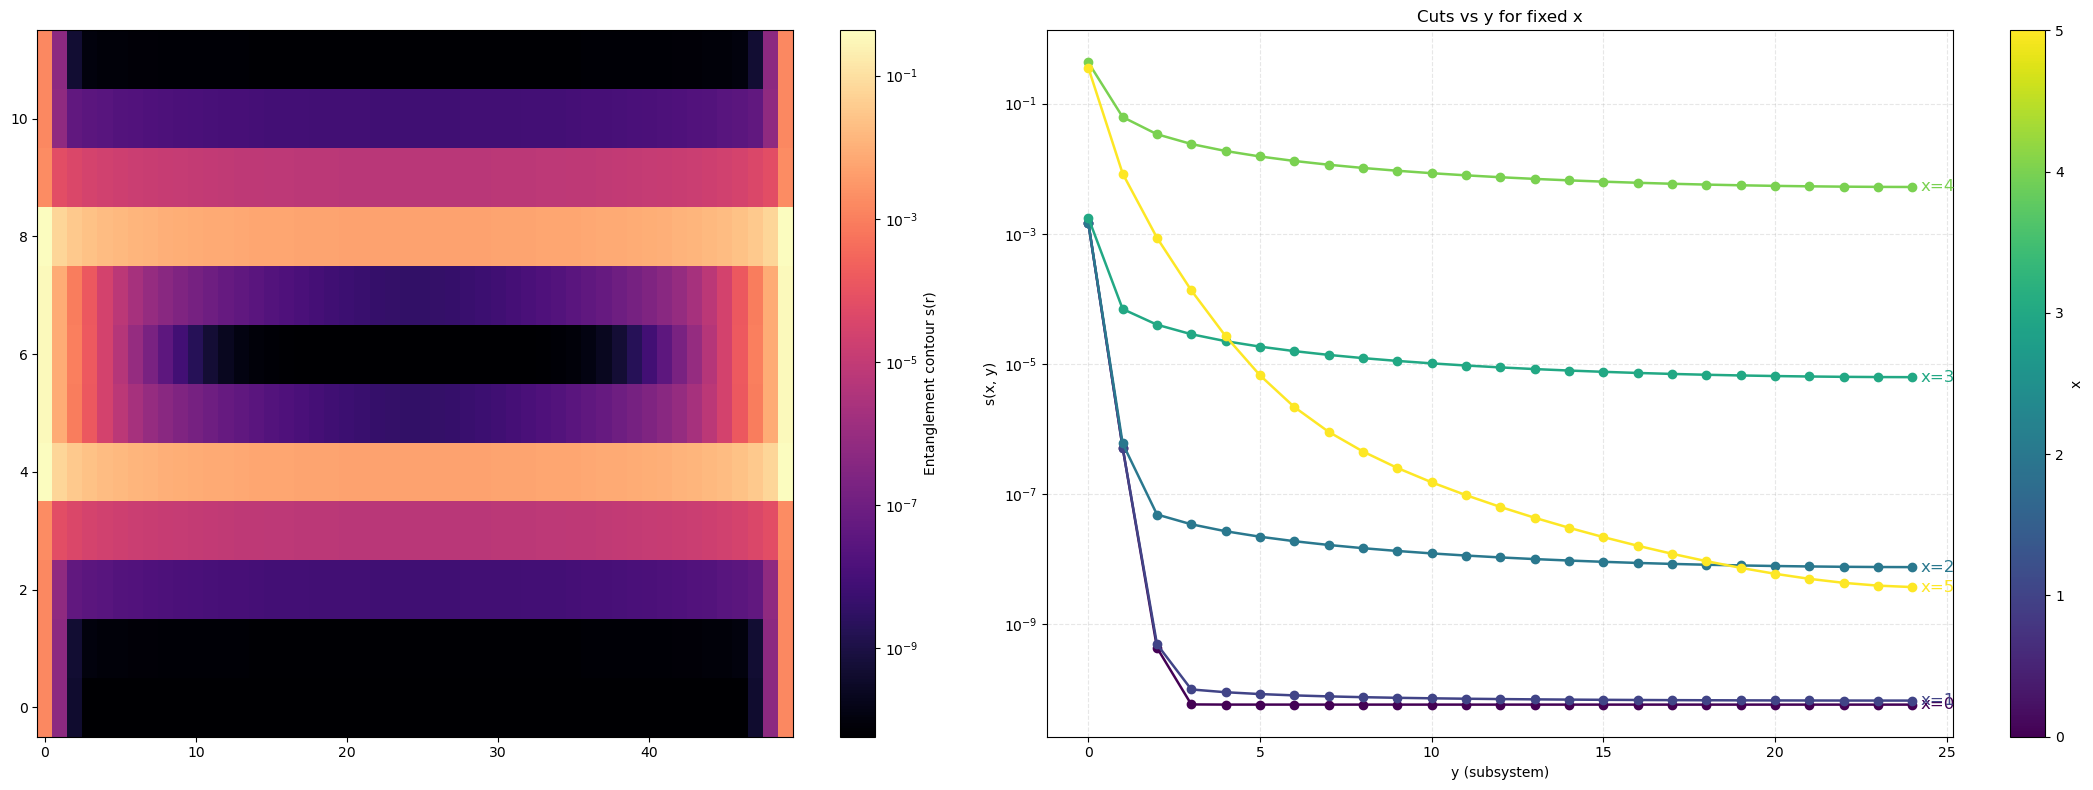

In [102]:
from matplotlib import colors

# --- Entanglement cut at y = Ny//2 (keep upper half; change yA for lower half) ---
y_cut = Ny // 2
yA = np.arange(y_cut, Ny)  # keep y >= Ny//2; use np.arange(0, y_cut) for lower half
xA = np.arange(Nx)

# Build flattened indices i = μ + 2*x + 2*Nx*y for the chosen region
sub_indices = []
for y in yA:
    for x in xA:
        sub_indices.append(0 + 2*x + 2*Nx*y)
        sub_indices.append(1 + 2*x + 2*Nx*y)
sub_indices = np.array(sub_indices, dtype=int)

# Reduced covariance for the subsystem
G_sub = G_gs[np.ix_(sub_indices, sub_indices)]  # shape: (2*Nx*len(yA), 2*Nx*len(yA))

# Entanglement contour on the subsystem.
# Use a helper instance with matching geometry (Nx, Ny_sub=len(yA)).
Ny_sub = len(yA)
contour_helper = classA_U1FGTN(Nx, Ny_sub, DW=False, alpha_1=1, alpha_2=1)
s_map = contour_helper.entanglement_contour(G_sub)  # shape: (Nx, Ny_sub)

# Plot: heatmap + y-cuts at fixed x with gradient colors
fig, axes = plt.subplots(1, 2, figsize=(22, 8), gridspec_kw={"width_ratios": [1, 1.2]})

# Heatmap
vmin = np.max([np.min(s_map[s_map > 0]), 1e-12])  # avoid zeros
vmax = np.max(s_map)
im2 = axes[0].imshow(
    s_map,
    origin="lower",
    cmap="magma",
    aspect="auto",
    norm=colors.LogNorm(vmin=vmin, vmax=vmax)
)
fig.colorbar(im2, ax=axes[0], label="Entanglement contour s(r)")

# y-cuts at fixed x
y_vals = np.arange(Ny_sub // 2)
x_list = np.arange(Nx//2)  # change to a subset if you want fewer lines
colors = plt.cm.viridis(np.linspace(0, 1, len(x_list)))
markers = ['o', '^']
for x_idx, color in zip(x_list, colors):
    y_curve = s_map[x_idx, :len(y_vals)]
    axes[1].plot(y_vals, y_curve, marker=markers[0], color=color, lw=1.8)
    # Annotate at the last point with a small offset
    x_end = y_vals[-1]
    y_end = y_curve[-1]
    axes[1].annotate(
        f"x={x_idx}",
        xy=(x_end, y_end),
        xytext=(6, 0),
        textcoords="offset points",
        color=color,
        fontsize=12,
        va="center"
    )

axes[1].set_xlabel("y (subsystem)")
axes[1].set_ylabel("s(x, y)")
axes[1].set_title("Cuts vs y for fixed x")
axes[1].grid(alpha=0.3, linestyle="--", linewidth=0.8)
axes[1].set_yscale('log')
axes[1].set_xscale('linear')

# Colorbar for x values
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=x_list.min(), vmax=x_list.max()))
sm.set_array([])
fig.colorbar(sm, ax=axes[1], label="x")

plt.tight_layout()
plt.show()


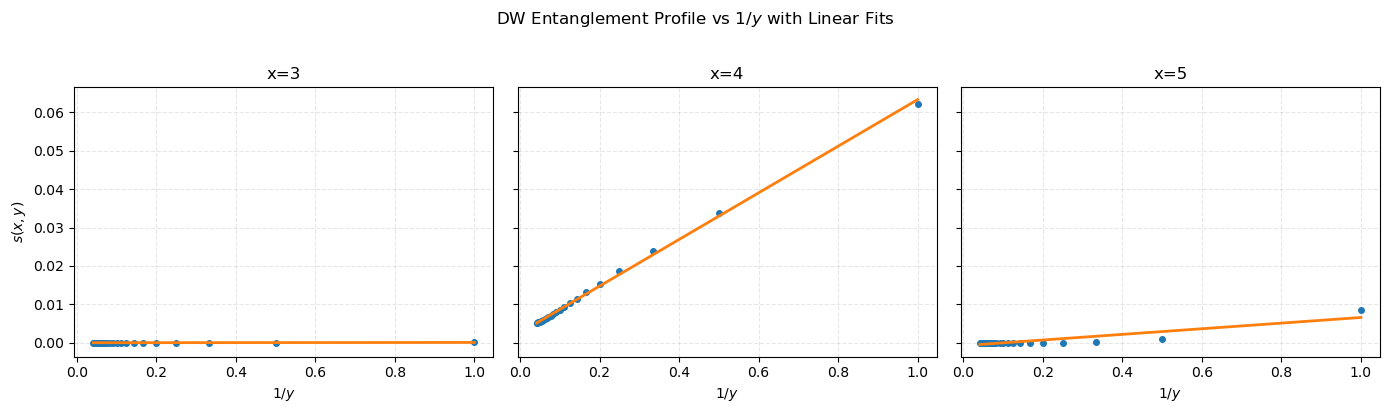

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

y_vals = np.arange(1, Ny_sub // 2)
s_curve_dw = s_map[4, int(y_vals[0]):int(y_vals[-1] + 1)]

x = 1.0 / y_vals
y = s_curve_dw

# Fit y = m x + b
m, b = np.polyfit(x, y, 1)
print(f"slope = {m:.6g}, intercept = {b:.6g}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, y, "o", ms=5, label="data")
ax.plot(x, m*x + b, "-", lw=2, label=f"fit: slope={m:.4g}")
ax.set_xlabel(r"$1/y$")
ax.set_ylabel(r"$s(x{=}4,y)$")
ax.set_title(r"DW Entanglement Profile vs $1/y$ with Linear Fit")
ax.grid(alpha=0.3, linestyle="--")
ax.legend()
plt.tight_layout()
plt.show()


DWs at x=(4, 8)
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(4, 8)
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(4, 8)
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(4, 8)
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(4, 8)
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(4, 8)
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initia

/tmp/ipykernel_3699843/3493408117.py:82: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


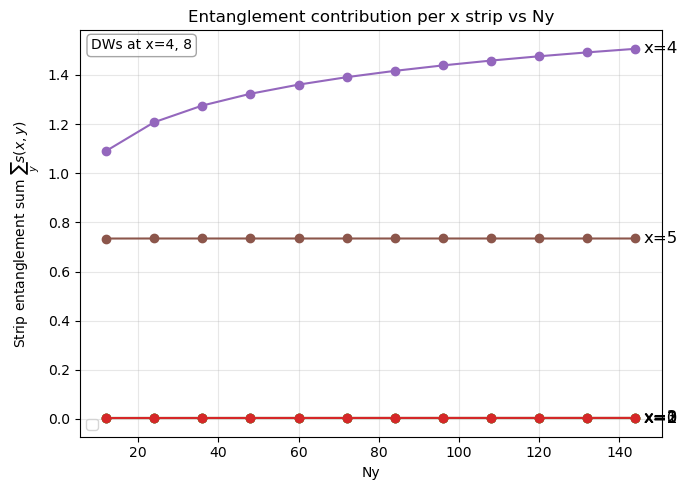

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from classA_U1FGTN import classA_U1FGTN

# ---- User inputs ----
Nx = 12
Ny_list = 12 * np.arange(1, 13)  # 12, 24, ..., 144
alpha_1, alpha_2 = 30, 1
periodic = True
x_list = np.arange(Nx // 2)
dw_text = f"DWs at x=4, 8"  # <-- fill in with your DW locations
# ---------------------

def entanglement_strip_sums(model, G_gs):
    Ny = model.Ny
    y_cut = Ny // 2
    yA = np.arange(y_cut, Ny)
    xA = np.arange(model.Nx)

    # Build flattened indices i = μ + 2*x + 2*Nx*y
    sub_indices = []
    for y in yA:
        for x in xA:
            sub_indices.append(0 + 2*x + 2*model.Nx*y)
            sub_indices.append(1 + 2*x + 2*model.Nx*y)
    sub_indices = np.array(sub_indices, dtype=int)

    # Reduced covariance
    G_sub = G_gs[np.ix_(sub_indices, sub_indices)]

    # Entanglement contour on the subsystem
    Ny_sub = len(yA)
    contour_helper = classA_U1FGTN(model.Nx, Ny_sub, DW=False, alpha_1=1, alpha_2=1)
    s_map = contour_helper.entanglement_contour(G_sub)  # shape: (Nx, Ny_sub)

    # Sum over y for each fixed x
    Sx = np.sum(s_map[:,], axis=1)  # shape: (Nx,)
    return Sx

# Compute Sx(Ny)
Sx_vs_Ny = {x: [] for x in x_list}

for Ny in Ny_list:
    model = classA_U1FGTN(Nx, Ny, DW=True, alpha_1=alpha_1, alpha_2=alpha_2)
    G_gs = model.G_CI_domain_wall(periodic=periodic)

    Sx = entanglement_strip_sums(model, G_gs)
    for x in x_list:
        Sx_vs_Ny[x].append(Sx[x])

# Plot Sx vs Ny for each x
plt.figure(figsize=(7, 5))
for x in x_list:
    curve = np.array(Sx_vs_Ny[x])
    plt.plot(Ny_list, curve, marker='o', lw=1.5)

    # annotate each curve at the last point
    plt.annotate(
        f"x={x}",
        xy=(Ny_list[-1], curve[-1]),
        xytext=(6, 0),
        textcoords="offset points",
        fontsize=12,
        va="center"
    )

plt.xlabel("Ny")
plt.ylabel("Strip entanglement sum $\\sum_y s(x,y)$")
plt.title("Entanglement contribution per x strip vs Ny")
plt.grid(alpha=0.3)

# textbox for DW locations
plt.gca().text(
    0.02, 0.98, dw_text,
    transform=plt.gca().transAxes,
    va="top", ha="left",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7, edgecolor="gray")
)

plt.tight_layout()
plt.legend()
plt.show()


slope = 0.167187, intercept = 0.675698, 1/6=0.166667


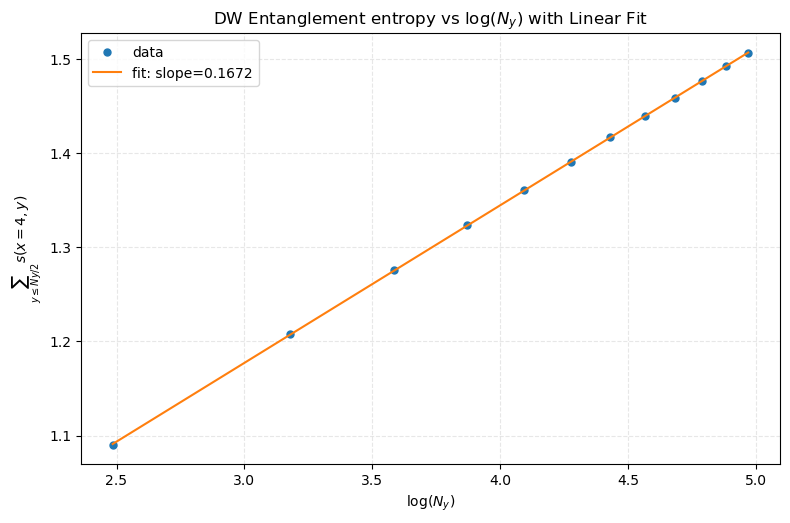

In [101]:
x = np.log(Ny_list)
Sx_dw = np.array(Sx_vs_Ny[4])
y = Sx_dw

# Fit y = m x + b
m, b = np.polyfit(x, y, 1)
print(f"slope = {m:.6g}, intercept = {b:.6g}, 1/6={1/6:.6g}")

# Plot with fit
fig, ax = plt.subplots(figsize=(8, 16/3))
ax.plot(x, y, "o", label="data", ms=5)
ax.plot(x, m*x + b, "-", label=f"fit: slope={m:.4g}")
ax.set_xlabel(r"$\log(N_y)$")
ax.set_ylabel(r"$\sum_{y\leq Ny/2} s(x{=}4,y)$")
ax.set_title(r"DW Entanglement entropy vs $\log(N_y)$ with Linear Fit")
ax.grid(alpha=0.3, linestyle="--")
ax.legend()
plt.tight_layout()
plt.show()

